<a href="https://colab.research.google.com/github/ahve19/Resampling_methods/blob/main/Resampling_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from scipy.optimize import minimize


pollution = pd.read_csv('gdrive/My Drive/Colab Notebooks/pollution_cleaneddata.csv')
bird = pd.read_csv('gdrive/My Drive/Colab Notebooks/bird_count.csv')

In [12]:
# Specify a polynomial regression model with degree p
# that predicts mortality as a function of the average July temperature in degrees F

X = pollution[['JULT']]
y = pollution['MORT']

degree = 4

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)

# Fit linear regression model
model_sklearn = LinearRegression()
model_sklearn.fit(X_poly, y)

# Predictions & Metrics
y_pred = model_sklearn.predict(X_poly)
print(f"\n--- Scikit-Learn Model Results (Degree {degree}) ---")
print(f"Intercept (Beta_0): {model_sklearn.intercept_:.4f}")
for i, coef in enumerate(model_sklearn.coef_, 1):
    print(f"Coefficient Beta_{i} (Temp^{i}): {coef:.4f}")
print(f"R-squared: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")


# Plot Fit with error



--- Scikit-Learn Model Results (Degree 4) ---
Intercept (Beta_0): 66946.2022
Coefficient Beta_1 (Temp^1): -3091.7521
Coefficient Beta_2 (Temp^2): 51.9941
Coefficient Beta_3 (Temp^3): -0.3650
Coefficient Beta_4 (Temp^4): 0.0009
R-squared: 0.2656
RMSE: 52.8639


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


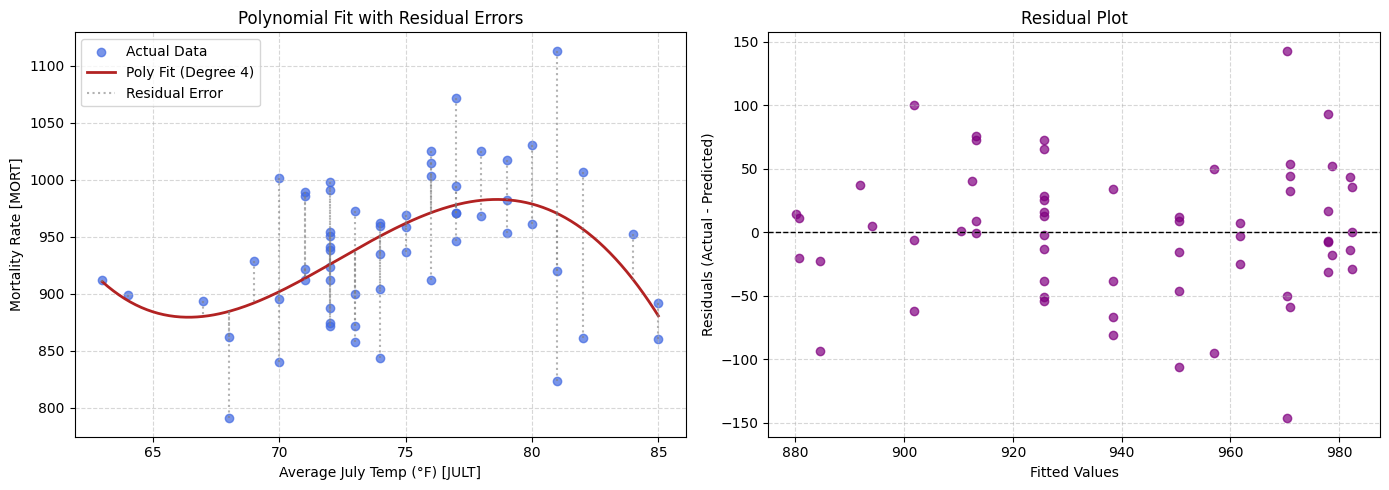

In [13]:
# 1. Create a smooth X range to plot a non-jagged fit curve
x_grid = np.linspace(X['JULT'].min(), X['JULT'].max(), 300).reshape(-1, 1)
x_grid_poly = poly.transform(x_grid)
y_grid_pred = model_sklearn.predict(x_grid_poly)

# 2. Set up a 2-panel plot (Fit with Errors + Residual Analysis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Fit Curve + Data Points + Residual Error Lines ---
ax1.scatter(X['JULT'], y, color='royalblue', alpha=0.7, label='Actual Data')
ax1.plot(
    x_grid,
    y_grid_pred,
    color='firebrick',
    linewidth=2,
    label=f'Poly Fit (Degree {degree})',
)
# Draw vertical error lines connecting data points to the model predictions
ax1.vlines(
    X['JULT'],
    y,
    y_pred,
    color='gray',
    linestyle=':',
    alpha=0.6,
    label='Residual Error',
)

ax1.set_xlabel('Average July Temp (°F) [JULT]')
ax1.set_ylabel('Mortality Rate [MORT]')
ax1.set_title('Polynomial Fit with Residual Errors')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Subplot 2: Residual (Error) Distribution Plot ---
residuals = y - y_pred
ax2.scatter(y_pred, residuals, color='purple', alpha=0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals (Actual - Predicted)')
ax2.set_title('Residual Plot')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [38]:
# set seed for reproducibility
set_seed = np.random.seed(0)

x = pollution[['JULT']].values
y = pollution['MORT']

X_train, X_test, y_train, y_test = train_test_split(
    x.reshape(-1, 1), y, test_size=0.5, random_state=0
)

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_train)

# Fit linear regression model
model = LinearRegression()
model.fit(X_poly, y_train)

# Make predictions
X_test = poly.fit_transform(X_test)
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse)
print(r2)

2362.910564451308
0.309418211909688


In [40]:
degrees = [1, 2, 3, 4, 5]
results = []

X_train, X_test, y_train, y_test = train_test_split(
    x.reshape(-1, 1), y, test_size=0.5, random_state=0
)

for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_poly = poly.fit_transform(X_train)

  # Fit linear regression model
  model = LinearRegression()
  model.fit(X_poly, y_train)

  # Make predictions
  X_test_poly = poly.fit_transform(X_test)
  y_pred = model.predict(X_test_poly)

  mse_deg = mean_squared_error(y_test, y_pred)
  r2_deg = r2_score(y_test, y_pred)

  results.append(
        {
            "degree": degree,
            "mse": mse_deg,
            "r2": r2_deg,
        })


# Convert results list to a Pandas DataFrame
df_results = pd.DataFrame(results)

# Clean up column names for presentation
df_results.columns = ["Degree", "MSE", "R²"]

# In Jupyter Notebook, display the formatted DataFrame directly:
df_results

,Degree,MSE,R²
0,1,3202.000744,0.064187
1,2,2874.583869,0.159877
2,3,2362.910564,0.309418
3,4,2557.706740,0.252487
4,5,3210.358626,0.061744


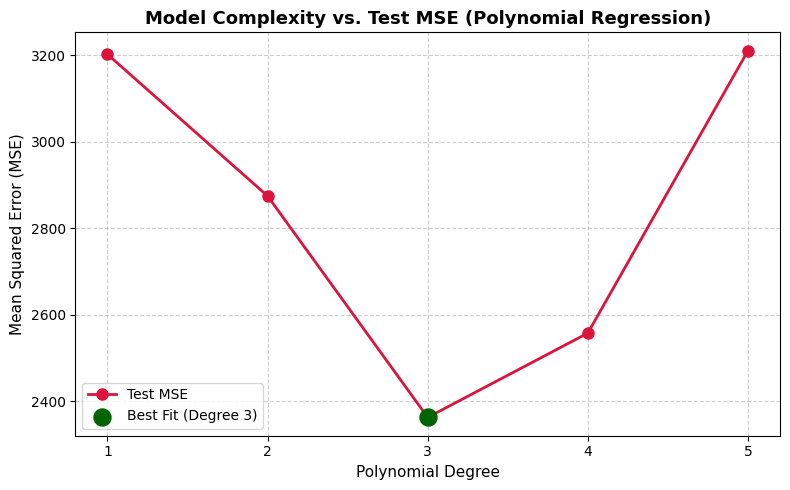

In [41]:
# Convert results list to DataFrame if not already done
df_results = pd.DataFrame(results)

plt.figure(figsize=(8, 5))

# Plot line with markers at each degree
plt.plot(
    df_results['degree'],
    df_results['mse'],
    marker='o',
    linestyle='-',
    color='crimson',
    linewidth=2,
    markersize=8,
    label='Test MSE',
)

# Highlight the degree with the minimum MSE
min_mse_row = df_results.loc[df_results['mse'].idxmin()]
plt.scatter(
    min_mse_row['degree'],
    min_mse_row['mse'],
    color='darkgreen',
    s=150,
    zorder=5,
    label=f"Best Fit (Degree {int(min_mse_row['degree'])})",
)

plt.title(
    'Model Complexity vs. Test MSE (Polynomial Regression)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.xticks(df_results['degree'])  # Force integer ticks for degrees
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
all_results = []

for seed in seeds:
    # Use seed directly in train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        x.reshape(-1, 1), y, test_size=0.5, random_state=seed
    )

    for degree in range(1, 6):
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # Use transform() on test data, not fit_transform()
        X_test_poly = poly.transform(X_test)
        y_pred = model.predict(X_test_poly)

        all_results.append(
            {
                "seed": seed,
                "degree": degree,
                "mse": mean_squared_error(y_test, y_pred),
                "r2": r2_score(y_test, y_pred),
            }
        )

# Combine into a single readable DataFrame
df_all = pd.DataFrame(all_results)

# Pivot table to easily compare MSE across seeds for each degree
mse_pivot = df_all.pivot(index="degree", columns="seed", values="mse")
print("mse")
print(mse_pivot)
mse_pivot = df_all.pivot(index="degree", columns="seed", values="r2")
print('r2')
print(mse_pivot)

mse
seed               1             2            3            4            5   \
degree                                                                       
1         5040.756601   3478.233759  3667.911949  4017.191740  2563.018524   
2         6264.876170   6425.207260  3508.538872  4456.842315  2407.977929   
3         4503.027465   4448.747104  2971.958990  2713.454582  2110.844327   
4        18958.881069   5675.699763  2970.789361  8003.489295  2143.221043   
5       137735.701656  14994.396773  2994.612072  6303.810746  2449.098585   

seed               6            7            8            9            10  
degree                                                                     
1         3747.668835  5080.687024  2929.449947  4716.857745  3084.204120  
2         4266.916605  4513.812841  3128.792506  4532.824707  3197.453043  
3         2828.417874  3704.058797  2927.527951  3986.232326  2578.987079  
4         9064.150466  4155.886684  3077.381300  4629.046446  2582.85

In [56]:
for degree in range(1, 6):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    # Calculate Mean Squared Error across 10 folds
    scores = cross_val_score(
        model,
        x.reshape(-1, 1),
        y,
        cv=10,
        scoring="neg_mean_squared_error",
    )
    print(f"Degree {degree} - Average MSE: {-scores.mean():.2f}")

Degree 1 - Average MSE: 3886.66
Degree 2 - Average MSE: 3645.20
Degree 3 - Average MSE: 3104.28
Degree 4 - Average MSE: 3215.78
Degree 5 - Average MSE: 3326.60


In [59]:
# 1. Setup parameters
p = 2  # Degree p = 2
k = 3  # 3-fold cross-validation
seeds = range(1, 11)
results = []

X_arr = (
    X.to_numpy().reshape(-1, 1) if hasattr(X, "to_numpy") else x.reshape(-1, 1)
)
y_arr = y.to_numpy() if hasattr(y, "to_numpy") else y

# 2. Iterate across 10 random seeds
for seed in seeds:
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    fold_mses = []

    for train_idx, test_idx in kf.split(X_arr):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Fit polynomial transformation
        poly = PolynomialFeatures(degree=p, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Train linear regression
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # Predict & calculate MSE for fold
        y_pred = model.predict(X_test_poly)
        fold_mses.append(mean_squared_error(y_test, y_pred))

    # Compute CV metrics across the 3 folds
    cv_mean_mse = np.mean(fold_mses)
    cv_var_mse = np.var(fold_mses, ddof=1)  # Variance across folds

    results.append(
        {
            "Seed": seed,
            "Mean CV MSE": cv_mean_mse,
            "Fold MSE Variance": cv_var_mse,
        }
    )

df_cv = pd.DataFrame(results)
print(df_cv.to_string(index=False))

print(f"\nOverall Mean MSE across seeds: {df_cv['Mean CV MSE'].mean():.2f}")
print(
    f"Variance of Mean MSE across seeds: {df_cv['Mean CV MSE'].var():.2f}"
)

 Seed  Mean CV MSE  Fold MSE Variance
    1  5175.994078       4.977409e+06
    2  5176.310229       8.728803e+06
    3  3513.029877       3.613457e+06
    4  3826.803794       1.312580e+06
    5  3924.199874       6.476729e+06
    6  5740.597705       2.605720e+06
    7  3758.749368       3.505452e+05
    8  3576.517064       1.458735e+06
    9  5723.806750       1.125033e+07
   10  3658.313780       1.279407e+06

Overall Mean MSE across seeds: 4407.43
Variance of Mean MSE across seeds: 859446.57


In [60]:
y = bird['count']
x = bird['yr']

def neg_log_likelihood(params, x, y):
    beta0, beta1 = params
    log_lambda = beta0 + beta1 * x
    lambda_ = np.exp(log_lambda)
    # Omitting sum(log(y!)) because it is constant wrt params
    return np.sum(lambda_ - y * log_lambda)

# Get the years from first count to prevent numeric overflow
x_centered = x - x[0]

# Optimize negative log-likelihood
initial_guess = [0.0, 0.0]
result = minimize(neg_log_likelihood, initial_guess, args=(x_centered, y), method='BFGS')

# Recover parameters on the original scale
beta0_centered, beta1 = result.x
beta0_original = beta0_centered - beta1 * x[0]

print(f"Optimization success: {result.success}")
print(f"Beta 0: {beta0_original:.5f}")
print(f"Beta 1: {beta1:.5f}")

Optimization success: True
Beta 0: 67.17924
Beta 1: -0.03244


Bootstrap Standard Error for Beta 1: 0.03384
Successful Bootstrap Samples: 837 / 1000


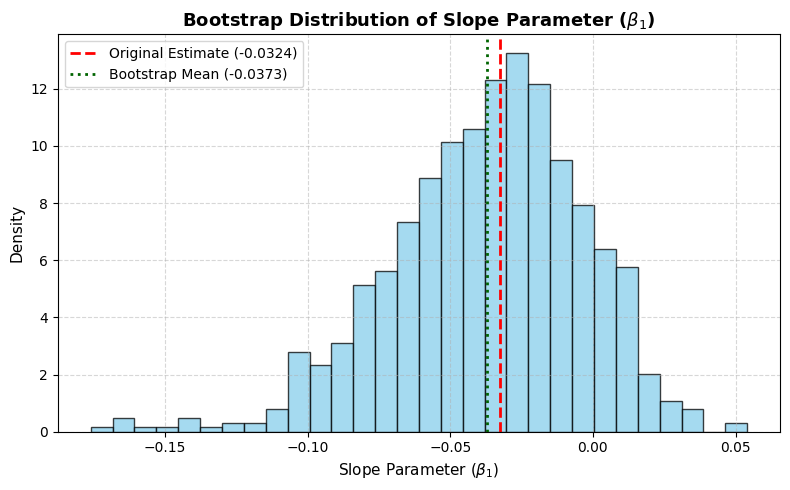

In [61]:
# Convert to NumPy arrays to ensure integer indexing works reliably
x_arr = np.array(x)
y_arr = np.array(y)
n_samples = len(y_arr)

# Bootstrap settings
n_bootstraps = 1000
bootstrap_beta1 = []

# Set seed for reproducibility
np.random.seed(42)

# --- Bootstrap Loop ---
for _ in range(n_bootstraps):
    # 1. Resample data with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    x_boot = x_arr[boot_indices]
    y_boot = y_arr[boot_indices]

    # Center using original x[0] for consistent parameter scaling
    x_boot_centered = x_boot - x_arr[0]

    # 2. Refit negative log-likelihood on bootstrap sample
    res = minimize(
        neg_log_likelihood,
        initial_guess,
        args=(x_boot_centered, y_boot),
        method="BFGS",
    )

    # Store slope estimate if optimization converged
    if res.success:
        bootstrap_beta1.append(res.x[1])

bootstrap_beta1 = np.array(bootstrap_beta1)

# --- Compute Standard Error ---
# Standard error is the sample standard deviation of the bootstrap distribution
se_beta1 = np.std(bootstrap_beta1, ddof=1)

print(f"Bootstrap Standard Error for Beta 1: {se_beta1:.5f}")
print(
    f"Successful Bootstrap Samples: {len(bootstrap_beta1)} / {n_bootstraps}"
)

# --- Plot Histogram ---
plt.figure(figsize=(8, 5))
plt.hist(
    bootstrap_beta1,
    bins=30,
    color="skyblue",
    edgecolor="black",
    alpha=0.75,
    density=True,
)

# Add reference lines for original point estimate and bootstrap mean
plt.axvline(
    beta1,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Original Estimate ({beta1:.4f})",
)
plt.axvline(
    np.mean(bootstrap_beta1),
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label=f"Bootstrap Mean ({np.mean(bootstrap_beta1):.4f})",
)

plt.xlabel(r"Slope Parameter ($\beta_1$)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title(
    r"Bootstrap Distribution of Slope Parameter ($\beta_1$)",
    fontsize=13,
    fontweight="bold",
)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()